In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/cleaned_supply_chain.csv")

print("Dataset loaded successfully!")
print("Rows:", len(df))

Dataset loaded successfully!
Rows: 1000


In [3]:
df[
    [
        "Product_Name",
        "Quantity",
        "Stock",
        "Reorder_Level"
    ]
].head(20)

,Product_Name,Quantity,Stock,Reorder_Level
0,Mouse,18,80,26
1,Office Chair,13,61,20
2,Monitor,9,54,23
3,Office Chair,5,48,20
4,Printer,18,68,27
5,Tablet,11,72,24
6,Desk,4,49,22
7,Desk,10,39,28
8,Desk,14,76,23
9,Laptop,3,6,24


In [4]:
# Low Stock Products

In [5]:
low_stock = df[
    df["Stock"] < df["Reorder_Level"]
]

print("Low Stock Records:", len(low_stock))

Low Stock Records: 167


In [6]:
low_stock[
    [
        "Product_Name",
        "Stock",
        "Reorder_Level"
    ]
].head(20)

,Product_Name,Stock,Reorder_Level
9,Laptop,6,24
13,Office Chair,7,12
14,Desk,21,22
15,Keyboard,20,30
21,Monitor,20,28
26,Mobile Phone,10,27
30,Mouse,17,27
46,Office Chair,5,29
50,Printer,19,20
62,Tablet,5,30


In [7]:
df["Inventory_Status"] = df.apply(
    lambda row:
    "Low Stock"
    if row["Stock"] < row["Reorder_Level"]
    else "Normal",
    axis=1
)

In [8]:
df[
    [
        "Product_Name",
        "Stock",
        "Reorder_Level",
        "Inventory_Status"
    ]
].head(20)

,Product_Name,Stock,Reorder_Level,Inventory_Status
0,Mouse,80,26,Normal
1,Office Chair,61,20,Normal
2,Monitor,54,23,Normal
3,Office Chair,48,20,Normal
4,Printer,68,27,Normal
5,Tablet,72,24,Normal
6,Desk,49,22,Normal
7,Desk,39,28,Normal
8,Desk,76,23,Normal
9,Laptop,6,24,Low Stock


In [9]:
inventory_status = df["Inventory_Status"].value_counts()

print(inventory_status)

Inventory_Status
Normal       833
Low Stock    167
Name: count, dtype: int64


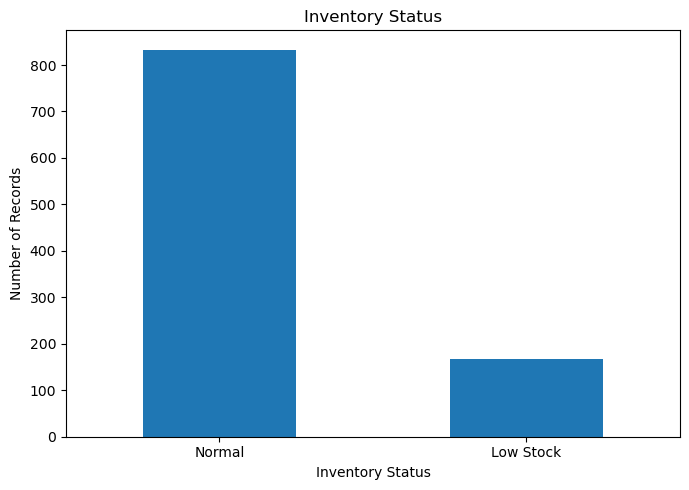

In [10]:
plt.figure(figsize=(7, 5))

inventory_status.plot(kind="bar")

plt.title("Inventory Status")
plt.xlabel("Inventory Status")
plt.ylabel("Number of Records")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [11]:
product_stock = (
    df.groupby("Product_Name")["Stock"]
    .mean()
    .sort_values()
)

product_stock

Product_Name
Office Chair    48.488372
Tablet          49.370787
Monitor         51.336634
Mobile Phone    51.566372
Headphones      52.918182
Desk            53.177570
Printer         53.514851
Keyboard        53.666667
Mouse           54.404255
Laptop          56.340206
Name: Stock, dtype: float64

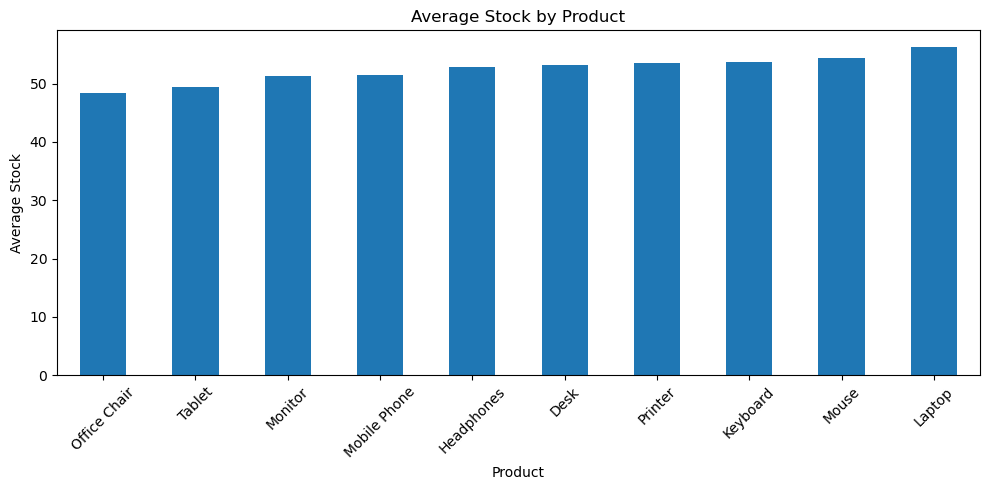

In [12]:
plt.figure(figsize=(10, 5))

product_stock.plot(kind="bar")

plt.title("Average Stock by Product")
plt.xlabel("Product")
plt.ylabel("Average Stock")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [13]:
df["Reorder_Quantity"] = (
    df["Reorder_Level"] - df["Stock"]
)

In [14]:
df["Reorder_Quantity"] = df["Reorder_Quantity"].clip(lower=0)

In [15]:
df[
    [
        "Product_Name",
        "Stock",
        "Reorder_Level",
        "Reorder_Quantity"
    ]
].head(20)

,Product_Name,Stock,Reorder_Level,Reorder_Quantity
0,Mouse,80,26,0
1,Office Chair,61,20,0
2,Monitor,54,23,0
3,Office Chair,48,20,0
4,Printer,68,27,0
5,Tablet,72,24,0
6,Desk,49,22,0
7,Desk,39,28,0
8,Desk,76,23,0
9,Laptop,6,24,18


In [16]:
reorder_products = df[
    df["Reorder_Quantity"] > 0
]

print(
    "Records requiring reorder:",
    len(reorder_products)
)

Records requiring reorder: 167


In [17]:
product_reorder = (
    df.groupby("Product_Name")["Reorder_Quantity"]
    .sum()
    .sort_values(ascending=False)
)

product_reorder

Product_Name
Mobile Phone    236
Tablet          214
Keyboard        189
Office Chair    180
Headphones      177
Desk            166
Mouse           149
Laptop          145
Monitor          86
Printer          75
Name: Reorder_Quantity, dtype: int64

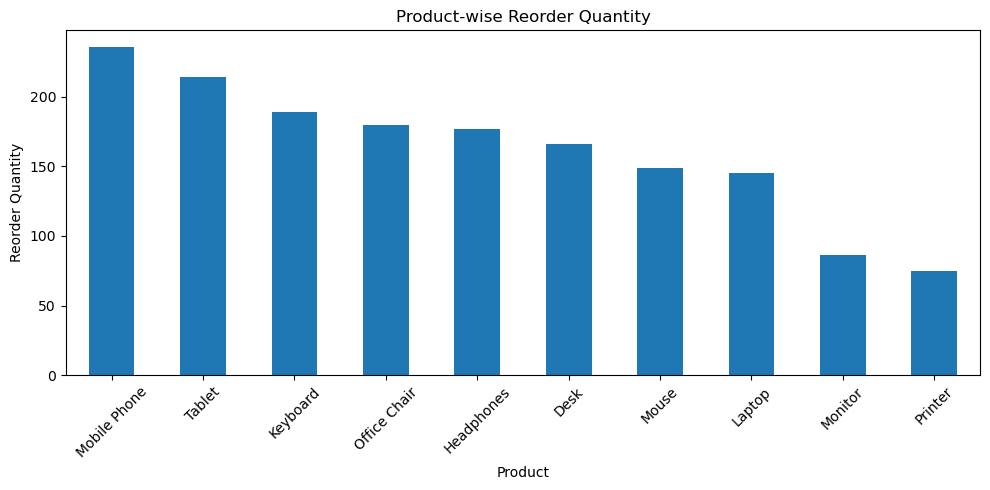

In [18]:
plt.figure(figsize=(10, 5))

product_reorder.plot(kind="bar")

plt.title("Product-wise Reorder Quantity")
plt.xlabel("Product")
plt.ylabel("Reorder Quantity")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [19]:
df["Inventory_Value"] = (
    df["Stock"] * df["Unit_Price"]
)

In [20]:
total_inventory_value = df["Inventory_Value"].sum()

print(
    "Total Inventory Value:",
    total_inventory_value
)

Total Inventory Value: 754256700


In [21]:
product_inventory_value = (
    df.groupby("Product_Name")["Inventory_Value"]
    .sum()
    .sort_values(ascending=False)
)

product_inventory_value

Product_Name
Laptop          273250000
Mobile Phone    145675000
Printer          81075000
Tablet           79092000
Monitor          62220000
Desk             56900000
Office Chair     29190000
Headphones       14552500
Keyboard          8211000
Mouse             4091200
Name: Inventory_Value, dtype: int64

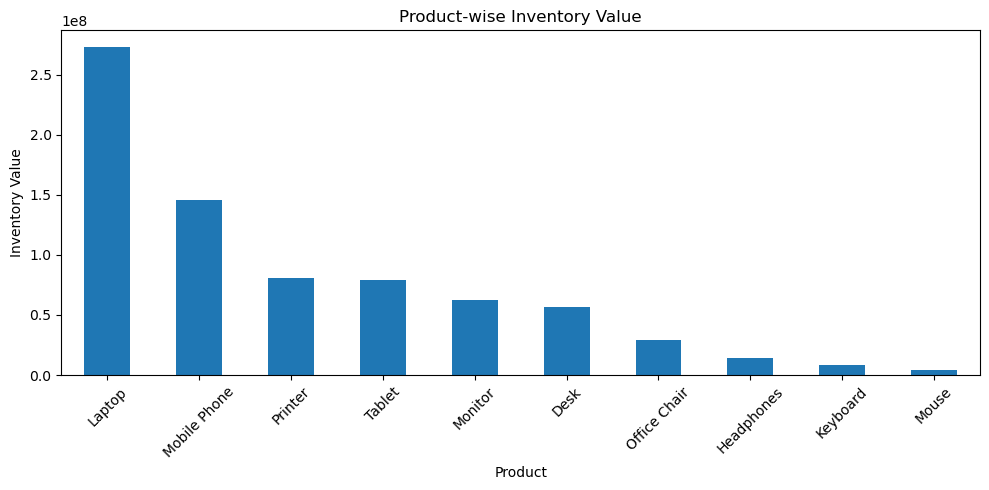

In [22]:
plt.figure(figsize=(10, 5))

product_inventory_value.plot(kind="bar")

plt.title("Product-wise Inventory Value")
plt.xlabel("Product")
plt.ylabel("Inventory Value")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [23]:
print("========== INVENTORY SUMMARY ==========")

print(
    "Total Inventory Value:",
    round(df["Inventory_Value"].sum(), 2)
)

print(
    "Low Stock Records:",
    len(low_stock)
)

print(
    "Records Requiring Reorder:",
    len(reorder_products)
)

print(
    "Total Reorder Quantity:",
    df["Reorder_Quantity"].sum()
)

print("========================================")

========== INVENTORY SUMMARY ==========
Total Inventory Value: 754256700
Low Stock Records: 167
Records Requiring Reorder: 167
Total Reorder Quantity: 1617


In [24]:
df.to_csv(
    "../data/inventory_analysis.csv",
    index=False
)

print("Inventory analysis saved successfully!")

Inventory analysis saved successfully!
